# 06 Initial EDA — NBA Lineup Stint Features

## Goal

We want to understand whether the full-season lineup stint dataset is usable for EDA, baseline recommendations, and first-pass modeling.

The final product goal is:

> Given game context, recommend a lineup or substitution option based on historical lineup performance.

Example contexts:
- Need points
- Need defense
- Protecting a lead
- Trailing late in the 4th
- Starter resting
- Opponent has a specific lineup on the floor

This notebook focuses on the first stage: understanding the data and building simple lineup-level summaries.

## 1. Imports and project paths

This notebook uses the team-perspective dataset:

`team_lineup_stint_features_v1_2024_25.parquet`

Each row represents **one team lineup during one stint**. Since each original stint has a home and away team, the team-perspective table has two rows per original stint.

In [9]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# If the notebook is opened from /notebooks, use the parent as the project root.
# If it is opened from the project root, use the current folder.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FEATURE_PATH = PROJECT_ROOT / "data/processed/final/team_lineup_stint_features_v1_2024_25.parquet"
MODELING_PATH = PROJECT_ROOT / "data/processed/final/modeling_lineup_stints_v1_2024_25.parquet"
LINEUP_SUMMARY_PATH = PROJECT_ROOT / "data/processed/final/lineup_summary_v1_2024_25.parquet"

print("Project root:", PROJECT_ROOT)
print("Feature path exists:", FEATURE_PATH.exists())

Project root: /content
Feature path exists: False


In [10]:
import os
FEATURE_PATH = "/content/team_lineup_stint_features_v1_2024_25.parquet"
print("Feature path exists:", os.path.exists(FEATURE_PATH))

Feature path exists: True


## 2. Load the dataset

Main checks:
- Number of rows and columns
- Number of games
- Number of unique lineups
- Whether the table has the expected team-perspective format

In [11]:
df = pd.read_parquet(FEATURE_PATH)

print("Shape:", df.shape)
print("Unique games:", df["game_id"].nunique())
print("Unique lineups:", df["lineup_key"].nunique())

display(df.head())

Shape: (81536, 36)
Unique games: 1230
Unique lineups: 3274


,stint_id,game_id,stint_number,period,is_overtime,start_clock,end_clock,start_seconds_remaining,end_seconds_remaining,duration_seconds,duration_minutes,team_id,opponent_team_id,is_home,lineup_ids,opponent_lineup_ids,lineup_names,opponent_lineup_names,score_for_start,score_against_start,score_for_end,score_against_end,points_for,points_against,net_points,ended_by_substitution,lineup_key,opponent_lineup_key,score_margin_start,score_margin_end,score_margin_change,points_for_per_min,points_against_per_min,net_points_per_min,net_points_per_48,is_zero_duration
0,0022400001_001,0022400001,1,1,False,PT12M00.00S,PT07M02.00S,720.0,422.0,298.0,4.966667,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",0,0,8,11,8,11,-3,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,0,-3,-3,1.610738,2.214765,-0.604027,-28.993289,False
1,0022400001_002,0022400001,2,1,False,PT07M02.00S,PT05M57.00S,422.0,357.0,65.0,1.083333,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",8,11,12,11,4,0,4,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,-3,1,4,3.692308,0.000000,3.692308,177.230769,False
2,0022400001_003,0022400001,3,1,False,PT05M57.00S,PT04M51.00S,357.0,291.0,66.0,1.100000,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",12,11,14,13,2,2,0,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,1,1,0,1.818182,1.818182,0.000000,0.000000,False
3,0022400001_004,0022400001,4,1,False,PT04M51.00S,PT04M27.00S,291.0,267.0,24.0,0.400000,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",14,13,14,16,0,3,-3,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,1,-2,-3,0.000000,7.500000,-7.500000,-360.000000,False
4,0022400001_005,0022400001,5,1,False,PT04M27.00S,PT00M26.30S,267.0,26.3,240.7,4.011667,1610612738,1610612737,1,"[201143, 201950, 1627759, 1628369, 1628401]","[203991, 1630552, 1630700, 1630811, 1642258]","[Al Horford, Jrue Holiday, Jaylen Brown, Jayso...","[Clint Capela, Jalen Johnson, Dyson Daniels, K...",14,16,28,29,14,13,1,True,201143-201950-1627759-1628369-1628401,203991-1630552-1630700-1630811-1642258,-2,-1,1,3.489821,3.240548,0.249273,11.965102,False


### Takeaway

Expected full-season shape:
- 1,230 games
- One row per team per lineup stint
- The row count should be roughly double the original home/away stint table

This dataset is the main file for EDA and first-pass modeling.

## 3. Dataset health checks

Before modeling, we need to check:
- Missing values
- Zero-duration rows
- Stint duration distribution
- Period distribution
- Extreme target values

Zero-duration rows are usually created by same-clock substitutions. They should generally be removed before modeling because no actual game time passed.

In [12]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))

print("Zero-duration distribution:")
display(df["is_zero_duration"].value_counts(dropna=False))
display(df["is_zero_duration"].value_counts(normalize=True, dropna=False))

,0
points_against_per_min,7210
net_points_per_min,7210
net_points_per_48,7210
points_for_per_min,7210
period,0
stint_number,0
game_id,0
stint_id,0
is_overtime,0
start_clock,0


Zero-duration distribution:


,count
is_zero_duration,
False,74326
True,7210


,proportion
is_zero_duration,
False,0.911573
True,0.088427


In [13]:
df_nonzero = df[df["duration_seconds"] > 0].copy()
df_30 = df[df["duration_seconds"] >= 30].copy()

print("Original:", df.shape)
print("Nonzero duration:", df_nonzero.shape)
print("At least 30 seconds:", df_30.shape)

print("\nUnique games:")
print("Original:", df["game_id"].nunique())
print("Nonzero:", df_nonzero["game_id"].nunique())
print("30+ seconds:", df_30["game_id"].nunique())

print("\nUnique lineups:")
print("Original:", df["lineup_key"].nunique())
print("Nonzero:", df_nonzero["lineup_key"].nunique())
print("30+ seconds:", df_30["lineup_key"].nunique())

Original: (81536, 36)
Nonzero duration: (74326, 36)
At least 30 seconds: (60678, 36)

Unique games:
Original: 1230
Nonzero: 1230
30+ seconds: 1230

Unique lineups:
Original: 3274
Nonzero: 3274
30+ seconds: 3274


### Takeaway

Use `df_nonzero` when you only need to remove impossible/no-time rows.

Use `df_30` when analyzing rates like `net_points_per_48`, because very short stints can create extreme and noisy per-48 values.

## 4. Stint duration and period distribution

This helps us understand the unit of analysis. A stint is usually short because substitutions happen often.

If most stints are short, individual stint-level outcomes will be noisy. That means lineup-level aggregation is more reliable than ranking single stints.

,duration_seconds
count,60678.000000
mean,113.974712
std,77.475415
min,30.000000
25%,58.700000
50%,91.000000
75%,143.475000
max,720.000000


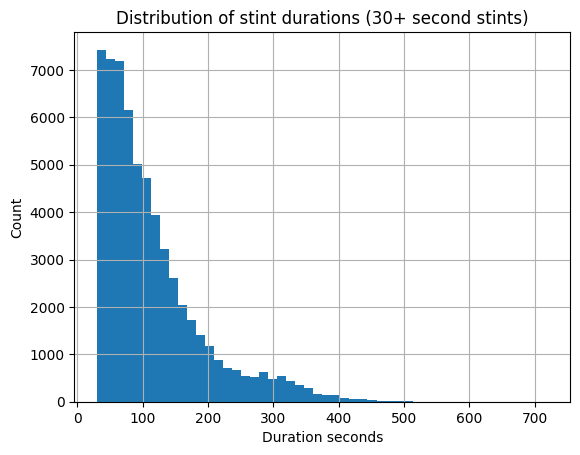

In [14]:
display(df_30["duration_seconds"].describe())

plt.figure()
df_30["duration_seconds"].hist(bins=50)
plt.title("Distribution of stint durations (30+ second stints)")
plt.xlabel("Duration seconds")
plt.ylabel("Count")
plt.show()

,count
period,
1,13370
2,17220
3,14224
4,15614
5,236
6,14


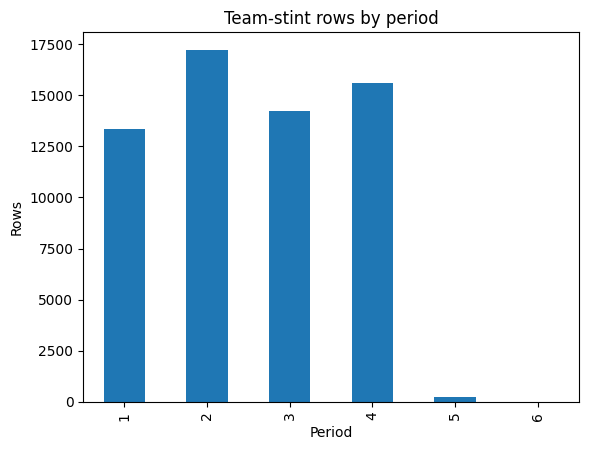

In [15]:
period_counts = df_30["period"].value_counts().sort_index()
display(period_counts)

plt.figure()
period_counts.plot(kind="bar")
plt.title("Team-stint rows by period")
plt.xlabel("Period")
plt.ylabel("Rows")
plt.show()

### Takeaway

Most stints are short, often around 1–2 minutes. Overtime periods should appear as period 5 or higher.

This matters because short segments make raw per-48 statistics noisy. We should aggregate by lineup and use minimum-minute thresholds.

## 5. Stint-level scoring distributions

At the individual stint level, `net_points_per_48` can be very extreme because short stints amplify small scoring changes.

This section confirms why raw stint-level performance is not enough for recommendation.

,net_points
count,60678.000000
mean,0.000000
std,3.577318
min,-22.000000
25%,-2.000000
50%,0.000000
75%,2.000000
max,22.000000


,net_points_per_48
count,6.067800e+04
mean,8.993322e-17
std,1.163274e+02
min,-5.760000e+02
25%,-6.926646e+01
50%,0.000000e+00
75%,6.926646e+01
max,5.760000e+02


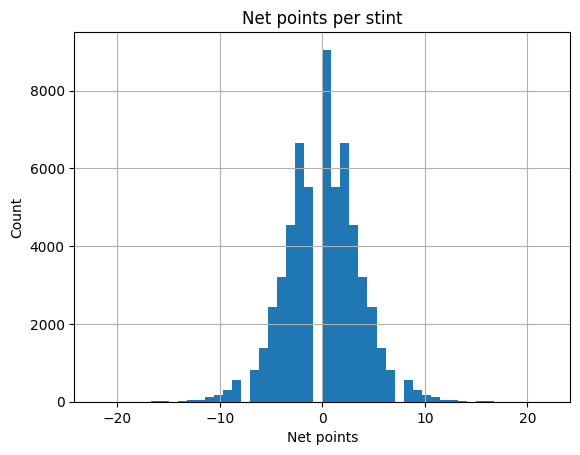

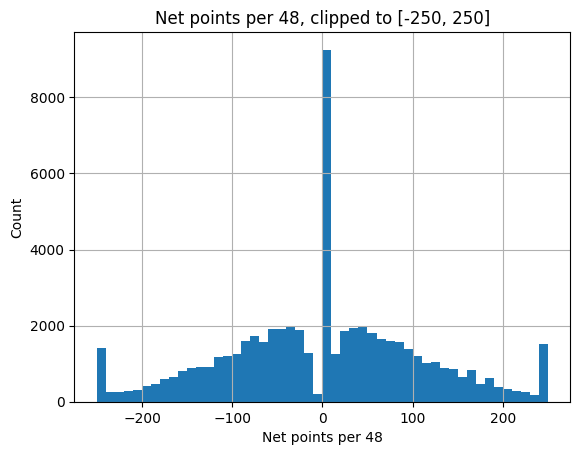

In [16]:
display(df_30["net_points"].describe())
display(df_30["net_points_per_48"].describe())

plt.figure()
df_30["net_points"].hist(bins=50)
plt.title("Net points per stint")
plt.xlabel("Net points")
plt.ylabel("Count")
plt.show()

plt.figure()
df_30["net_points_per_48"].clip(-250, 250).hist(bins=50)
plt.title("Net points per 48, clipped to [-250, 250]")
plt.xlabel("Net points per 48")
plt.ylabel("Count")
plt.show()

### Takeaway

The mean of `net_points` and `net_points_per_48` should be close to 0 because every stint appears from both teams' perspectives.

Extreme values are expected, especially for short stints. For recommendation, we should aggregate lineups and apply sample-size controls.

## 6. Build lineup-level summary table

This is the most important EDA table.

Each row becomes one team-lineup combination across the season, with:
- Total minutes
- Number of stints
- Number of games
- Points for/against
- Net points
- Points for per 48
- Points against per 48
- Net points per 48

This gives us the first baseline for lineup rankings.

In [17]:
def build_lineup_summary(data: pd.DataFrame) -> pd.DataFrame:
    summary = (
        data
        .groupby(["team_id", "lineup_key"])
        .agg(
            total_seconds=("duration_seconds", "sum"),
            total_minutes=("duration_minutes", "sum"),
            stints=("stint_id", "count"),
            games=("game_id", "nunique"),
            points_for=("points_for", "sum"),
            points_against=("points_against", "sum"),
            net_points=("net_points", "sum"),
        )
        .reset_index()
    )

    summary["points_for_per_48"] = (
        summary["points_for"] / summary["total_minutes"] * 48
    )

    summary["points_against_per_48"] = (
        summary["points_against"] / summary["total_minutes"] * 48
    )

    summary["net_points_per_48"] = (
        summary["net_points"] / summary["total_minutes"] * 48
    )

    return summary


lineup_summary = build_lineup_summary(df_30)

print("Lineup summary shape:", lineup_summary.shape)
display(lineup_summary.sort_values("total_minutes", ascending=False).head(20))

Lineup summary shape: (3274, 12)


,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48
1423,1610612750,201144-203497-203944-1628978-1629638,76464.3,1274.405000,736,51,2941,2943,-2,110.771693,110.847023,-0.075329
1830,1610612754,204456-1626167-1627783-1628418-1629614,55901.5,931.691667,530,38,2212,2177,35,113.960448,112.157277,1.803172
3084,1610612765,202699-203501-1627736-1630191-1630595,48557.1,809.285000,481,32,1812,1897,-85,107.472646,112.514133,-5.041487
764,1610612744,201939-202710-203110-1626172-1627741,46415.0,773.583333,441,27,1920,1674,246,119.133901,103.869870,15.264031
1586,1610612752,1626157-1626166-1628384-1628404-1628969,45082.1,751.368333,405,45,1817,1682,135,116.076225,107.451960,8.624266
1431,1610612750,201144-203497-203944-1630162-1630183,39418.2,656.970000,311,52,1542,1426,116,112.662679,104.187406,8.475273
1608,1610612752,1626157-1628384-1628404-1628969-1628973,35800.2,596.670000,264,48,1393,1388,5,112.061944,111.659711,0.402232
971,1610612746,201587-201935-1626181-1627739-1627826,33839.5,563.991667,303,29,1222,1304,-82,104.001537,110.980363,-6.978827
200,1610612739,1627747-1627777-1628378-1628386-1629636,32533.5,542.225000,316,20,1321,1247,74,116.940385,110.389598,6.550786
1359,1610612749,201572-203081-203507-1627752-1628398,32148.7,535.811667,269,14,1284,1292,-8,115.025491,115.742161,-0.716670


### Takeaway

The most-used lineups are usually starting lineups or main rotation groups.

For recommendations, total minutes matter because a lineup with 25 minutes of history is much less reliable than a lineup with 300+ minutes.

## 7. Minutes threshold sensitivity

This checks how many lineups remain if we require more historical playing time.

This is important because a lineup recommender should not trust tiny samples too much.

,min_minutes,qualified_lineups
0,20,1394
1,50,465
2,100,218
3,200,80
4,500,12


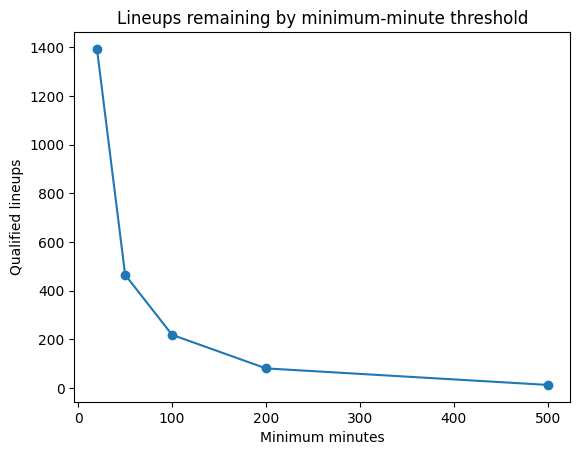

In [18]:
threshold_rows = []

for minutes in [20, 50, 100, 200, 500]:
    threshold_rows.append({
        "min_minutes": minutes,
        "qualified_lineups": int((lineup_summary["total_minutes"] >= minutes).sum())
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure()
plt.plot(threshold_df["min_minutes"], threshold_df["qualified_lineups"], marker="o")
plt.title("Lineups remaining by minimum-minute threshold")
plt.xlabel("Minimum minutes")
plt.ylabel("Qualified lineups")
plt.show()

### Takeaway

As the minutes threshold increases, the number of usable lineups drops quickly. This suggests:
- Small-sample lineups are common
- We should use shrinkage-adjusted ratings
- Adding previous seasons could help if the team wants more historical sample size

## 8. Best offensive, defensive, and balanced lineups

This section creates three simple recommendation modes:

- Need points: rank by `points_for_per_48`
- Need stops: rank by lowest `points_against_per_48`
- Balanced: rank by `net_points_per_48`

This is a useful baseline before machine learning.

In [19]:
MIN_MINUTES = 50

qualified = lineup_summary[lineup_summary["total_minutes"] >= MIN_MINUTES].copy()

best_offense = qualified.sort_values("points_for_per_48", ascending=False)
best_defense = qualified.sort_values("points_against_per_48", ascending=True)
best_balanced = qualified.sort_values("net_points_per_48", ascending=False)

print("Qualified lineups:", qualified.shape[0])

print("\nBest offensive lineups:")
display(best_offense.head(20))

print("\nBest defensive lineups:")
display(best_defense.head(20))

print("\nBest balanced lineups:")
display(best_balanced.head(20))

Qualified lineups: 465

Best offensive lineups:


,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48
647,1610612743,201566-1627750-1629008-1631124-1631128,3534.1,58.901667,27,5,177,143,34,144.240401,116.533205,27.707196
2437,1610612760,1627936-1628983-1629026-1629652-1630198,3537.4,58.956667,30,4,171,164,7,139.220897,133.521796,5.699101
2459,1610612760,1628392-1628983-1629026-1629652-1630598,4187.6,69.793333,36,6,202,155,47,138.924444,106.600439,32.324004
1007,1610612746,201587-202695-203992-1626181-1627732,4243.0,70.716667,31,6,204,144,60,138.468065,97.742164,40.725901
2264,1610612758,201942-1627734-1628368-1628370-1628989,4153.8,69.230000,37,4,199,164,35,137.974866,113.707930,24.266936
2430,1610612760,1627936-1628392-1629026-1630198-1630598,3535.1,58.918333,30,5,168,137,31,136.867415,111.612118,25.255297
2496,1610612760,1628983-1629652-1631096-1631114-1641717,4138.7,68.978333,34,6,194,145,49,134.998913,100.901249,34.097664
18,1610612737,1627777-1629027-1629611-1630168-1630249,3405.0,56.750000,32,2,158,138,20,133.638767,116.722467,16.916300
229,1610612739,1628378-1628386-1629636-1630171-1630596,9976.9,166.281667,71,14,458,372,86,132.209404,107.384057,24.825347
520,1610612742,202681-202691-1629023-1629029-1641726,4846.0,80.766667,34,7,222,188,34,131.935617,111.729261,20.206356



Best defensive lineups:


,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48
2453,1610612760,1627936-1629652-1630198-1630598-1631096,4307.0,71.783333,34,6,171,121,50,114.344091,80.910146,33.433945
2482,1610612760,1628392-1629026-1630198-1630598-1631114,3516.4,58.606667,32,5,141,102,39,115.481743,83.539984,31.941759
2228,1610612757,203924-1629014-1630166-1630625-1630703,3559.0,59.316667,38,4,126,109,17,101.961225,88.204552,13.756673
1084,1610612747,2544-1626156-1629060-1629216-1629629,3486.9,58.115000,29,5,121,107,14,99.939775,88.376495,11.563280
1465,1610612751,1626156-1627732-1629651-1630533-1630549,4143.6,69.060000,42,3,152,130,22,105.647263,90.356212,15.291051
2403,1610612759,101108-203084-1630170-1631110-1641705,6335.9,105.598333,44,9,236,200,36,107.274420,90.910526,16.363895
3064,1610612765,202699-1627736-1630191-1630595-1631093,5624.7,93.745000,50,5,216,183,33,110.597899,93.700997,16.896901
1694,1610612753,202709-203484-1628371-1628976-1629021,3547.0,59.116667,35,3,125,116,9,101.494220,94.186637,7.307584
140,1610612738,201143-201950-1628369-1628401-1629674,3453.6,57.560000,27,4,125,113,12,104.239055,94.232106,10.006949
1828,1610612754,204456-1626167-1627783-1628396-1628418,4083.0,68.050000,43,4,165,134,31,116.385011,94.518736,21.866275



Best balanced lineups:


,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48
1007,1610612746,201587-202695-203992-1626181-1627732,4243.0,70.716667,31,6,204,144,60,138.468065,97.742164,40.725901
2496,1610612760,1628983-1629652-1631096-1631114-1641717,4138.7,68.978333,34,6,194,145,49,134.998913,100.901249,34.097664
2453,1610612760,1627936-1629652-1630198-1630598-1631096,4307.0,71.783333,34,6,171,121,50,114.344091,80.910146,33.433945
2459,1610612760,1628392-1628983-1629026-1629652-1630598,4187.6,69.793333,36,6,202,155,47,138.924444,106.600439,32.324004
2482,1610612760,1628392-1629026-1630198-1630598-1631114,3516.4,58.606667,32,5,141,102,39,115.481743,83.539984,31.941759
647,1610612743,201566-1627750-1629008-1631124-1631128,3534.1,58.901667,27,5,177,143,34,144.240401,116.533205,27.707196
135,1610612738,201143-201950-1627759-1628401-1628436,4229.3,70.488333,30,5,192,153,39,130.745041,104.187454,26.557586
993,1610612746,201587-201935-202695-203992-1626181,11160.1,186.001667,100,11,488,387,101,125.934355,99.870073,26.064283
2430,1610612760,1627936-1628392-1629026-1630198-1630598,3535.1,58.918333,30,5,168,137,31,136.867415,111.612118,25.255297
546,1610612742,202681-202691-203915-203939-1629029,4118.3,68.638333,39,4,174,138,36,121.681276,96.505840,25.175436


### Takeaway

These rankings are useful for finding interesting lineups, but they are not final recommendations yet.

Reasons:
- They do not fully adjust for opponent strength
- They do not account for score/time context
- They are still affected by sample size
- They are score-per-time, not possession-based ratings

Still, this is a strong first baseline.

## 9. Shrinkage-adjusted lineup ratings

Raw lineup ratings can overrate low-minute lineups.

Shrinkage pulls a lineup's rating toward the team's average. This makes the ranking more stable.

Conceptually:

`adjusted rating = lineup rating weighted by minutes + team average weighted by prior strength`

In [20]:
team_summary = (
    df_30
    .groupby("team_id")
    .agg(
        team_minutes=("duration_minutes", "sum"),
        team_points_for=("points_for", "sum"),
        team_points_against=("points_against", "sum"),
        team_net_points=("net_points", "sum"),
    )
    .reset_index()
)

team_summary["team_points_for_per_48"] = (
    team_summary["team_points_for"] / team_summary["team_minutes"] * 48
)

team_summary["team_points_against_per_48"] = (
    team_summary["team_points_against"] / team_summary["team_minutes"] * 48
)

team_summary["team_net_points_per_48"] = (
    team_summary["team_net_points"] / team_summary["team_minutes"] * 48
)

lineup_summary = lineup_summary.merge(team_summary, on="team_id", how="left")

# k = prior minutes. Higher k means more conservative shrinkage.
k = 50

lineup_summary["shrunk_points_for_per_48"] = (
    (lineup_summary["total_minutes"] / (lineup_summary["total_minutes"] + k))
    * lineup_summary["points_for_per_48"]
    +
    (k / (lineup_summary["total_minutes"] + k))
    * lineup_summary["team_points_for_per_48"]
)

lineup_summary["shrunk_points_against_per_48"] = (
    (lineup_summary["total_minutes"] / (lineup_summary["total_minutes"] + k))
    * lineup_summary["points_against_per_48"]
    +
    (k / (lineup_summary["total_minutes"] + k))
    * lineup_summary["team_points_against_per_48"]
)

lineup_summary["shrunk_net_points_per_48"] = (
    (lineup_summary["total_minutes"] / (lineup_summary["total_minutes"] + k))
    * lineup_summary["net_points_per_48"]
    +
    (k / (lineup_summary["total_minutes"] + k))
    * lineup_summary["team_net_points_per_48"]
)

qualified_shrunk = lineup_summary[lineup_summary["total_minutes"] >= MIN_MINUTES].copy()

display(
    qualified_shrunk.sort_values("shrunk_points_for_per_48", ascending=False)
    .head(20)
)

display(
    qualified_shrunk.sort_values("shrunk_net_points_per_48", ascending=False)
    .head(20)
)

,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48,team_minutes,team_points_for,team_points_against,team_net_points,team_points_for_per_48,team_points_against_per_48,team_net_points_per_48,shrunk_points_for_per_48,shrunk_points_against_per_48,shrunk_net_points_per_48
647,1610612743,201566-1627750-1629008-1631124-1631128,3534.1,58.901667,27,5,177,143,34,144.240401,116.533205,27.707196,3865.871667,9627,9296,331,119.532162,115.422352,4.109811,132.896112,116.023179,16.872933
2459,1610612760,1628392-1628983-1629026-1629652-1630598,4187.6,69.793333,36,6,202,155,47,138.924444,106.600439,32.324004,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,130.856787,106.769891,24.086896
2437,1610612760,1627936-1628983-1629026-1629652-1630198,3537.4,58.956667,30,4,171,164,7,139.220897,133.521796,5.699101,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,130.214801,121.353943,8.860858
229,1610612739,1628378-1628386-1629636-1630171-1630596,9976.9,166.281667,71,14,458,372,86,132.209404,107.384057,24.825347,3835.843333,9660,8920,740,120.880849,111.620826,9.260024,129.590468,108.363513,21.226955
219,1610612739,1628378-1628386-1629622-1629636-1630596,13980.6,233.010000,101,20,635,560,75,130.809836,115.359856,15.449981,3835.843333,9660,8920,740,120.880849,111.620826,9.260024,129.055660,114.699273,14.356387
2430,1610612760,1627936-1628392-1629026-1630198-1630598,3535.1,58.918333,30,5,168,137,31,136.867415,111.612118,25.255297,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,128.938538,109.497830,19.440708
235,1610612739,1628386-1629622-1629631-1629636-1629660,7032.2,117.203333,68,5,322,280,42,131.873382,114.672506,17.200876,3835.843333,9660,8920,740,120.880849,111.620826,9.260024,128.586207,113.759941,14.826267
2496,1610612760,1628983-1629652-1631096-1631114-1641717,4138.7,68.978333,34,6,194,145,49,134.998913,100.901249,34.097664,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,128.525676,103.466915,25.058760
199,1610612739,1627747-1627777-1628378-1628386-1629622,23765.1,396.085000,217,14,1065,968,97,129.063206,117.308154,11.755053,3835.843333,9660,8920,740,120.880849,111.620826,9.260024,128.146076,116.670682,11.475394
2824,1610612763,1628379-1628991-1630217-1641744-1642377,6254.5,104.241667,48,9,285,272,13,131.233512,125.247422,5.986090,3793.115000,9601,9138,463,121.495921,115.636884,5.859037,128.076910,122.132006,5.944904


,team_id,lineup_key,total_seconds,total_minutes,stints,games,points_for,points_against,net_points,points_for_per_48,points_against_per_48,net_points_per_48,team_minutes,team_points_for,team_points_against,team_net_points,team_points_for_per_48,team_points_against_per_48,team_net_points_per_48,shrunk_points_for_per_48,shrunk_points_against_per_48,shrunk_net_points_per_48
1007,1610612746,201587-202695-203992-1626181-1627732,4243.0,70.716667,31,6,204,144,60,138.468065,97.742164,40.725901,3852.146667,8974,8596,378,111.821288,107.111186,4.710101,127.431156,101.622747,25.808409
2496,1610612760,1628983-1629652-1631096-1631114-1641717,4138.7,68.978333,34,6,194,145,49,134.998913,100.901249,34.097664,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,128.525676,103.466915,25.058760
2453,1610612760,1627936-1629652-1630198-1630598-1631096,4307.0,71.783333,34,6,171,121,50,114.344091,80.910146,33.433945,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,116.500101,91.624370,24.875732
2459,1610612760,1628392-1628983-1629026-1629652-1630598,4187.6,69.793333,36,6,202,155,47,138.924444,106.600439,32.324004,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,130.856787,106.769891,24.086896
2482,1610612760,1628392-1629026-1630198-1630598-1631114,3516.4,58.606667,32,5,141,102,39,115.481743,83.539984,31.941759,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,117.375582,94.343390,23.032192
993,1610612746,201587-201935-202695-203992-1626181,11160.1,186.001667,100,11,488,387,101,125.934355,99.870073,26.064283,3852.146667,8974,8596,378,111.821288,107.111186,4.710101,122.944320,101.404196,21.540124
229,1610612739,1628378-1628386-1629636-1630171-1630596,9976.9,166.281667,71,14,458,372,86,132.209404,107.384057,24.825347,3835.843333,9660,8920,740,120.880849,111.620826,9.260024,129.590468,108.363513,21.226955
2869,1610612763,203935-1628379-1628991-1629630-1629634,11065.5,184.425000,123,6,497,401,96,129.353396,104.367629,24.985767,3793.115000,9601,9138,463,121.495921,115.636884,5.859037,127.677492,106.771224,20.906268
2421,1610612760,1627936-1628392-1628983-1629026-1629652,28598.2,476.636667,273,25,1221,1008,213,122.961585,101.511284,21.450301,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,122.641994,102.033004,20.608990
2430,1610612760,1627936-1628392-1629026-1630198-1630598,3535.1,58.918333,30,5,168,137,31,136.867415,111.612118,25.255297,3828.106667,9538,8534,1004,119.595414,107.006423,12.588991,128.938538,109.497830,19.440708


### Takeaway

Shrinkage-adjusted ratings are better for recommendation than raw per-48 ratings because they reduce the impact of small samples.

For a first baseline recommender:
- Need points → `shrunk_points_for_per_48`
- Need defense → low `shrunk_points_against_per_48`
- Balanced → `shrunk_net_points_per_48`

## 10. Context EDA: score margin and period

A recommendation system should consider game context.

This section checks whether lineup performance differs by:
- Leading/trailing
- Close game vs blowout
- Period
- Home vs away

This is the bridge between simple lineup rankings and context-aware modeling.

In [21]:
context_df = df_30.copy()

context_df["score_margin_bucket"] = pd.cut(
    context_df["score_margin_start"],
    bins=[-100, -10, -5, 5, 10, 100],
    labels=["trailing_10_plus", "trailing_6_to_10", "close", "leading_6_to_10", "leading_10_plus"],
)

context_summary = (
    context_df
    .groupby(["score_margin_bucket"], observed=False)
    .agg(
        rows=("stint_id", "count"),
        avg_net_points=("net_points", "mean"),
        avg_net_points_per_48=("net_points_per_48", "mean"),
        avg_points_for=("points_for", "mean"),
        avg_points_against=("points_against", "mean"),
    )
    .reset_index()
)

display(context_summary)

period_summary = (
    context_df
    .groupby("period")
    .agg(
        rows=("stint_id", "count"),
        avg_net_points=("net_points", "mean"),
        avg_net_points_per_48=("net_points_per_48", "mean"),
        avg_points_for=("points_for", "mean"),
        avg_points_against=("points_against", "mean"),
    )
    .reset_index()
)

display(period_summary)

,score_margin_bucket,rows,avg_net_points,avg_net_points_per_48,avg_points_for,avg_points_against
0,trailing_10_plus,11517,0.174004,4.904592,4.349570,4.175567
1,trailing_6_to_10,8341,0.107661,1.412945,4.122647,4.014986
2,close,22892,-0.003975,0.035392,4.895466,4.899441
3,leading_6_to_10,7757,-0.114735,-1.729033,4.025783,4.140518
4,leading_10_plus,10171,-0.188870,-5.473371,4.207846,4.396716


,period,rows,avg_net_points,avg_net_points_per_48,avg_points_for,avg_points_against
0,1,13370,0.0,-2.019493e-17,5.129095,5.129095
1,2,17220,0.0,3.301012e-18,3.900000,3.900000
2,3,14224,0.0,-3.996303e-18,4.860236,4.860236
3,4,15614,0.0,-9.101354e-18,4.129307,4.129307
4,5,236,0.0,1.204310e-16,4.877119,4.877119
5,6,14,0.0,0.000000e+00,5.857143,5.857143


### Takeaway

Context features like score margin and period should be included in modeling.

For example:
- A lineup that is good overall may not be the best choice when trailing
- A defensive lineup may be preferred when protecting a lead
- Late-game and overtime situations may need separate analysis

## 11. Player-level on-court summaries

This section expands each lineup into player rows.

Important caution:

This is **not isolated player impact**. It tells us how teams performed while a player was on the floor, but it does not fully control for teammates, opponents, or game context.

In [22]:
def parse_lineup_key(lineup_key: str) -> list[int]:
    return [int(x) for x in str(lineup_key).split("-") if x != ""]


player_df = df_30.copy()
player_df["player_id"] = player_df["lineup_key"].apply(parse_lineup_key)
player_df = player_df.explode("player_id")
player_df["player_id"] = player_df["player_id"].astype(int)

player_summary = (
    player_df
    .groupby(["team_id", "player_id"])
    .agg(
        total_minutes=("duration_minutes", "sum"),
        net_points=("net_points", "sum"),
        points_for=("points_for", "sum"),
        points_against=("points_against", "sum"),
        stints=("stint_id", "count"),
        games=("game_id", "nunique"),
    )
    .reset_index()
)

player_summary["net_points_per_48"] = (
    player_summary["net_points"] / player_summary["total_minutes"] * 48
)

player_summary["points_for_per_48"] = (
    player_summary["points_for"] / player_summary["total_minutes"] * 48
)

player_summary["points_against_per_48"] = (
    player_summary["points_against"] / player_summary["total_minutes"] * 48
)

display(
    player_summary[player_summary["total_minutes"] >= 100]
    .sort_values("net_points_per_48", ascending=False)
    .head(20)
)

,team_id,player_id,total_minutes,net_points,points_for,points_against,stints,games,net_points_per_48,points_for_per_48,points_against_per_48
95,1610612741,1631207,140.168333,81,385,304,66,9,27.738077,131.841476,104.103399
49,1610612739,1630171,334.635000,165,894,729,152,26,23.667578,128.235241,104.567663
459,1610612760,1631119,334.661667,155,859,704,162,16,22.231408,123.205028,100.973620
461,1610612760,1641717,540.078333,247,1405,1158,241,44,21.952371,124.870775,102.918404
225,1610612748,1630528,142.666667,61,365,304,61,11,20.523364,122.803738,102.280374
521,1610612763,1631246,116.708333,48,313,265,69,6,19.741521,128.731167,108.989647
457,1610612760,1631096,655.395000,244,1688,1444,313,32,17.870139,123.626210,105.756071
51,1610612739,1630596,833.850000,293,2166,1873,367,71,16.866343,124.684296,107.817953
458,1610612760,1631114,1111.688333,348,2830,2482,524,69,15.025794,122.192521,107.166727
31,1610612738,1630573,472.890000,148,1170,1022,201,30,15.022521,118.759119,103.736598


### Takeaway

Player-level summaries help identify players associated with strong or weak lineups.

But these should not be treated as causal. For better individual impact estimates, we would need regression models that control for teammates, opponents, and context.

## 12. Save modeling-ready datasets

This saves two useful handoff files:

1. `modeling_lineup_stints_v1_2024_25.parquet`
   - Stint-level team perspective
   - Removes rows under 30 seconds

2. `lineup_summary_v1_2024_25.parquet`
   - Aggregated lineup-level table
   - Includes raw and shrinkage-adjusted ratings

These are the files teammates can use for EDA and first-pass modeling.

In [23]:
model_df = df_30.copy()

model_df.to_parquet(MODELING_PATH, index=False)

lineup_summary.to_parquet(LINEUP_SUMMARY_PATH, index=False)

print("Saved modeling data:", MODELING_PATH)
print("Shape:", model_df.shape)
print("Unique games:", model_df["game_id"].nunique())
print("Unique lineups:", model_df["lineup_key"].nunique())

print("\nSaved lineup summary:", LINEUP_SUMMARY_PATH)
print("Shape:", lineup_summary.shape)

OSError: Cannot save file into a non-existent directory: '/content/data/processed/final'

## 13. Baseline recommender functions

These are simple functions your team can use before building machine learning models.

They recommend historically strong lineups by team and situation.

In [ ]:
def recommend_lineups(team_id: int, mode: str = "balanced", min_minutes: int = 50, top_n: int = 10) -> pd.DataFrame:
    candidates = lineup_summary[
        (lineup_summary["team_id"] == team_id)
        & (lineup_summary["total_minutes"] >= min_minutes)
    ].copy()

    if mode == "offense":
        sort_col = "shrunk_points_for_per_48"
        ascending = False
    elif mode == "defense":
        sort_col = "shrunk_points_against_per_48"
        ascending = True
    elif mode == "balanced":
        sort_col = "shrunk_net_points_per_48"
        ascending = False
    else:
        raise ValueError("mode must be one of: offense, defense, balanced")

    cols = [
        "team_id",
        "lineup_key",
        "total_minutes",
        "games",
        "points_for_per_48",
        "points_against_per_48",
        "net_points_per_48",
        "shrunk_points_for_per_48",
        "shrunk_points_against_per_48",
        "shrunk_net_points_per_48",
    ]

    return candidates.sort_values(sort_col, ascending=ascending)[cols].head(top_n)


# Example usage:
# recommend_lineups(team_id=1610612747, mode="offense", min_minutes=50, top_n=10)

## 14. Main EDA conclusions

1. The full-season team-perspective lineup dataset is usable.
2. Zero-duration rows should be filtered out before modeling.
3. Stint-level performance is noisy because most stints are short.
4. Lineup-level aggregation is more useful than individual stint rankings.
5. Minimum-minute thresholds matter a lot.
6. Raw per-48 ratings should be treated carefully.
7. Shrinkage-adjusted ratings are better for baseline recommendations.
8. Player-level summaries are useful, but they are not causal.
9. Context features like score margin, period, home/away, and opponent lineup should be included in modeling.

## 15. Recommended next EDA before modeling

Before training ML models, explore:

### A. Team-specific lineup rankings
Do the best lineups make basketball sense for each team?

### B. Stability by minutes threshold
Check whether top lineups stay similar at 20, 50, 100, and 200 minute thresholds.

### C. Context-specific rankings
Rank lineups separately for:
- Close games
- Trailing
- Leading
- Fourth quarter
- Overtime

### D. Opponent effects
Check whether certain lineups perform very differently depending on the opponent.

### E. Possession-based stats
Current data uses score-per-time stats. For a stronger model, add:
- possessions
- points per possession
- offensive rating
- defensive rating
- turnover rate
- free throw rate
- three-point attempt rate

### F. Modeling target decision
Decide whether the first model predicts:
- `points_for_per_48` for offense recommendations
- `net_points_per_48` for balanced recommendations
- future `offensive_rating` once possessions are added

### G. Train/test split strategy
Avoid random row splits only. Prefer splitting by date/game so the model is tested on future games.